In [44]:
import random
from typing import List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import datasets

import transformers
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments, pipeline,
)

print("datasets version:", datasets.__version__)
print("transformers version:", transformers.__version__)
print("torch version:", torch.__version__)
print("numpy version:", np.__version__)

datasets version: 4.8.4
transformers version: 5.5.0
torch version: 2.5.1+cu121
numpy version: 2.3.5


In [45]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

SEED = 42
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

display(device)
print("seed:", SEED, end='')

device(type='cuda')

seed: 42

## Dataset: emotion

I download dataset emotion

In [46]:
dataset = datasets.load_dataset('emotion')

In [47]:
display(dataset)
display(dataset.shape)
display(dataset['train'][:3])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

{'train': (16000, 2), 'validation': (2000, 2), 'test': (2000, 2)}

{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong'],
 'label': [0, 0, 3]}

In [48]:
df_train = pd.DataFrame(dataset['train'])
label_name = dataset['train'].features['label'].names
df_train['label_name'] = df_train['label'].apply(lambda x: label_name[x])
display(df_train)

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger
...,...,...,...
15995,i just had a very brief time in the beanbag an...,0,sadness
15996,i am now turning and i feel pathetic that i am...,0,sadness
15997,i feel strong and good overall,1,joy
15998,i feel like this was such a rude comment and i...,3,anger


In [49]:
df_train['label_name'].value_counts()

label_name
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

In [50]:
df_train.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [51]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        16000 non-null  object
 1   label       16000 non-null  int64 
 2   label_name  16000 non-null  object
dtypes: int64(1), object(2)
memory usage: 375.1+ KB


In [52]:
df_train.describe()

,label
count,16000.000000
mean,1.565937
std,1.501430
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,5.000000


In [53]:
print('train shape:', dataset['train'].shape)
print('val shape:', dataset['validation'].shape)
print('test shape:', dataset['test'].shape)

train shape: (16000, 2)
val shape: (2000, 2)
test shape: (2000, 2)


Мы классифицируем текст по эмоциям -> 6 типов эмоций: joy, sadness, anger, fear, love, surprise

In [54]:
MODEL_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model name:", MODEL_NAME)

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[str]]:
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = dataset.map(tokenize_batch, batched=True)

tokenized_datasets = tokenized_datasets.remove_columns(column_names=['text'])
display(tokenized_datasets)
df_train = pd.DataFrame(tokenized_datasets['train'])
df_train.head()

Tokenizer loaded: BertTokenizer
Model name: bert-base-uncased


DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

,label,input_ids,token_type_ids,attention_mask
0,0,"[101, 1045, 2134, 2102, 2514, 26608, 102]","[0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1]"
1,0,"[101, 1045, 2064, 2175, 2013, 3110, 2061, 2062...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,3,"[101, 10047, 9775, 1037, 3371, 2000, 2695, 104...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
3,2,"[101, 1045, 2572, 2412, 3110, 16839, 9080, 128...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,3,"[101, 1045, 2572, 3110, 24665, 7140, 11714, 102]","[0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1]"


In [55]:
example = tokenized_datasets['train'][0]

print("Keys:", example.keys())
print("Labels:", example['label'])
print('Token Ids:', example['input_ids'][:20])
print('Attention mask:', example['attention_mask'][:20])

print('\nВостанновленный текст\n', tokenizer.decode(example['input_ids']))

Keys: dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])
Labels: 0
Token Ids: [101, 1045, 2134, 2102, 2514, 26608, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1]

Востанновленный текст
 [CLS] i didnt feel humiliated [SEP]


In [56]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets['train'][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

input_ids: shape=(3, 23)
token_type_ids: shape=(3, 23)
attention_mask: shape=(3, 23)
labels: shape=(3,)


In [57]:
id2label = {id: value for id, value in enumerate(label_name)}
label2id = {value: id for id, value in enumerate(label_name)}
print("id2labels:", id2label)
print("labels2id:", label2id)

id2labels: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
labels2id: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}


In [58]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_name),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model class: BertForSequenceClassification
Number of labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [59]:
text_classification = pipeline(
    task='text-classification',
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

pipeline_outputs = text_classification(dataset['train'][:5]['text'])

predicted_df = pd.DataFrame({
    'text': dataset['train'][:5]['text'],
    'labels': [item['label'] for item in pipeline_outputs],
    'score': [item['score'] for item in pipeline_outputs]
})

predicted_df

,text,labels,score
0,i didnt feel humiliated,anger,0.242651
1,i can go from feeling so hopeless to so damned...,anger,0.215658
2,im grabbing a minute to post i feel greedy wrong,anger,0.256883
3,i am ever feeling nostalgic about the fireplac...,anger,0.236795
4,i am feeling grouchy,anger,0.199466


In [60]:
def compute_metric(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weighted = f1_score(labels, preds, average='weighted')

    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
    }

In [61]:
common_training_kwargs = dict(
    output_dir='outputs/s13_bert_finetuning_demo',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    report_to='none'
)

training_args = TrainingArguments(
    eval_strategy='epoch',
    save_strategy='epoch',
    **common_training_kwargs
)
training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [62]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metric,
)
train_result = trainer.train()
display(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.482680,0.205644,0.933000,0.907630,0.933304


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.482680,0.205644,0.933000,0.907630,0.933304
2,0.495989,0.192263,0.936000,0.904760,0.935085


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.482680,0.205644,0.933000,0.907630,0.933304
2,0.495989,0.192263,0.936000,0.904760,0.935085
3,0.004988,0.189996,0.938000,0.910001,0.938024


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.482680,0.205644,0.933000,0.907630,0.933304
2,0.495989,0.192263,0.936000,0.904760,0.935085
3,0.004988,0.189996,0.938000,0.910001,0.938024
4,0.003150,0.248665,0.943500,0.920676,0.943448


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.482680,0.205644,0.933000,0.907630,0.933304
2,0.495989,0.192263,0.936000,0.904760,0.935085
3,0.004988,0.189996,0.938000,0.910001,0.938024
4,0.003150,0.248665,0.943500,0.920676,0.943448
5,0.000406,0.304117,0.939500,0.914435,0.939305


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.482680,0.205644,0.933000,0.907630,0.933304
2,0.495989,0.192263,0.936000,0.904760,0.935085
3,0.004988,0.189996,0.938000,0.910001,0.938024
4,0.003150,0.248665,0.943500,0.920676,0.943448
5,0.000406,0.304117,0.939500,0.914435,0.939305


TrainOutput(global_step=10000, training_loss=0.1709631669329392, metrics={'train_runtime': 1079.0843, 'train_samples_per_second': 74.137, 'train_steps_per_second': 9.267, 'total_flos': 1695437529174432.0, 'train_loss': 0.1709631669329392, 'epoch': 5.0})

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.653765,10.952987,0.00002,0.001,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.963201,5.338380,0.00002,0.002,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.655137,8.484043,0.00002,0.003,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.572651,8.559548,0.00002,0.004,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.667514,6.350678,0.00002,0.005,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.802738,6.126669,0.00002,0.006,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.539879,7.000060,0.00002,0.007,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.595199,7.044021,0.00002,0.008,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.480270,9.443381,0.00002,0.009,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.759255,9.823541,0.00002,0.010,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


C:\Users\makwe\AppData\Local\Temp\ipykernel_23924\300801727.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_logs['smooth'] = train_logs['loss'].rolling(100).mean()


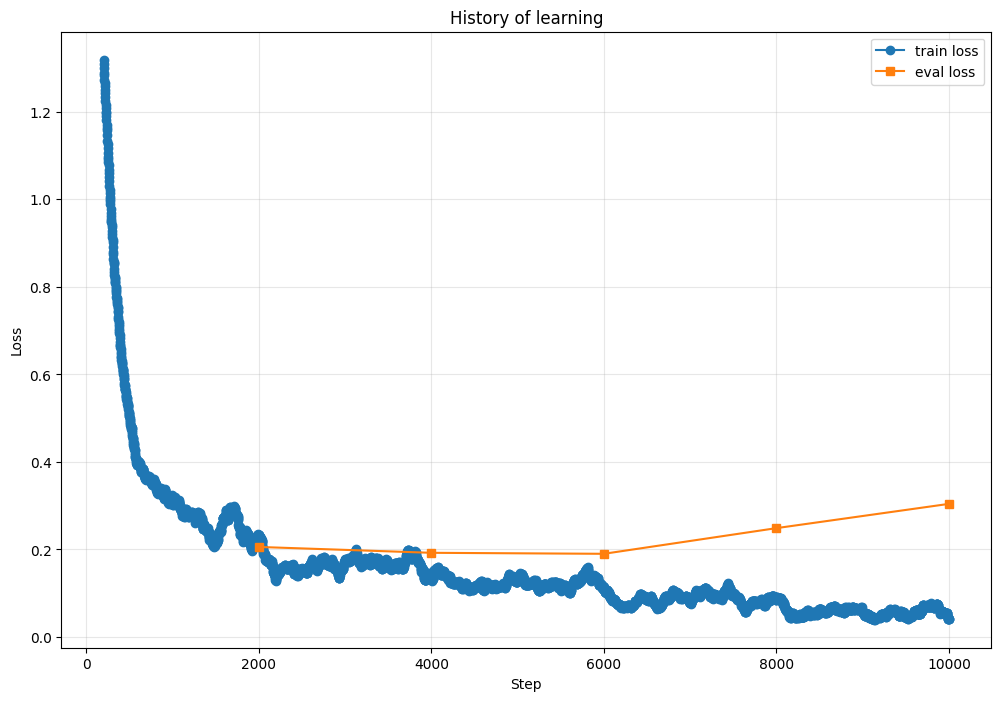

In [63]:
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(12, 8))

if 'loss' in history_df.columns:
    train_logs = history_df.dropna(subset=['loss'])
    train_logs['smooth'] = train_logs['loss'].rolling(100).mean()
    plt.plot(train_logs['step'], train_logs['smooth'], marker='o', label='train loss')

if 'eval_loss' in history_df.columns:
    eval_logs = history_df.dropna(subset=['eval_loss'])
    plt.plot(eval_logs['step'], eval_logs['eval_loss'], marker='s', label='eval loss')

plt.title('History of learning')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('./artifacts/training_curves.png')
plt.show()

In [64]:
from transformers.utils.notebook import NotebookProgressCallback

trainer.remove_callback(NotebookProgressCallback)

val_metrics = trainer.evaluate(tokenized_datasets['validation'])
test_metrics = trainer.evaluate(tokenized_datasets['test'])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f'{k}: {v:.4f}' if isinstance(v, (int, float)) else f'{k}: {v}')

print('\nTest metrics:')
for k, v in test_metrics.items():
    print(f'{k}: {v:.4f}' if isinstance(v, (int, float)) else f'{k}: {v}')

Validation metrics:
eval_loss: 0.2488
eval_accuracy: 0.9435
eval_f1_macro: 0.9207
eval_f1_weighted: 0.9434
eval_runtime: 7.4037
eval_samples_per_second: 270.1360
eval_steps_per_second: 33.7670
epoch: 5.0000

Test metrics:
eval_loss: 0.2687
eval_accuracy: 0.9275
eval_f1_macro: 0.8770
eval_f1_weighted: 0.9272
eval_runtime: 6.0523
eval_samples_per_second: 330.4520
eval_steps_per_second: 41.3070
epoch: 5.0000


Classification report on test:
              precision    recall  f1-score   support

     sadness       0.97      0.98      0.97       581
         joy       0.95      0.95      0.95       695
        love       0.83      0.79      0.81       159
       anger       0.97      0.91      0.93       275
        fear       0.86      0.92      0.89       224
    surprise       0.73      0.70      0.71        66

    accuracy                           0.93      2000
   macro avg       0.88      0.87      0.88      2000
weighted avg       0.93      0.93      0.93      2000



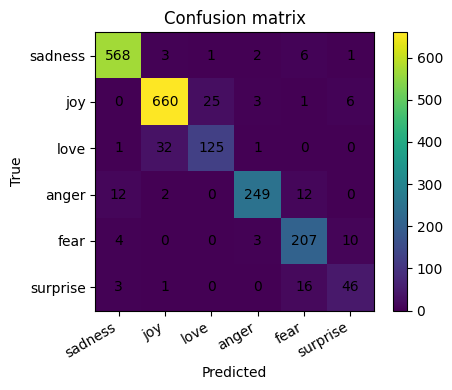

In [65]:
test_output = trainer.predict(tokenized_datasets['test'])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=[id2label[i] for i in range(len(id2label))],
        zero_division=0,
    )
)

cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_name)))
ax.set_yticks(range(len(label_name)))
ax.set_xticklabels(label_name, rotation=30, ha='right')
ax.set_yticklabels(label_name)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('./artifacts/confusion_matrix.png')
plt.show()

In [66]:
test_text = [dataset['test'][i]['text'] for i in range(len(dataset['test']))]

true_labels = [id2label[i] for i in test_true]
pred_labels = [id2label[i] for i in test_preds]
# print(len(dataset['test']))
# print(len(true_labels))
# print(len(pred_labels))
df_sample_predictions = pd.DataFrame({
    'text': test_text,
    'true_label': true_labels,
    'pred_label': pred_labels
})

display(df_sample_predictions.head())

df_sample_predictions.to_csv('./artifacts/sample_predictions.csv', index=False)

,text,true_label,pred_label
0,im feeling rather rotten so im not very ambiti...,sadness,sadness
1,im updating my blog because i feel shitty,sadness,sadness
2,i never make her separate from me because i do...,sadness,sadness
3,i left with my bouquet of red and yellow tulip...,joy,joy
4,i was feeling a little vain when i did this one,sadness,sadness
